# 11 · Visualization: Histograms

**Project:** Developer Technology Trends: Current Usage and Future Demand (IBM Data Analyst Professional Certificate, Capstone)

**Objective:** Use histograms (on SQL query results) to study compensation, experience, time spent searching, desired databases, work arrangements and job satisfaction.

**Data:** Stack Overflow Developer Survey loaded into a SQLite database (table `main`, 65,437 rows)

**Tools:** SQLite, SQL, pandas, Matplotlib

### Key results
- Most desired databases: PostgreSQL (24,005 mentions), SQLite, MySQL, MongoDB and Redis.
- Work arrangement: Hybrid 23,015 · Remote 20,831 · In-person 10,960.
- Median job satisfaction rises from 7 (up to 10 years of experience) to 8 (11+ years).

> Based on an IBM Skills Network hands-on lab: the task instructions and setup cells come from the course, the solution code and the analysis are my own.

[← 10](10_sql_data_visualization.ipynb) · [Project README](../README.md) · [12 →](12_viz_box_plots.ipynb)

In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab, you will perform the following:


- Visualize the distribution of data using histograms.

- Visualize relationships between features.

- Explore data composition and comparisons.


## Demo: Working with database


#### Download the database file.


In [1]:
!wget -O survey-data.sqlite https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

#### Install the required libraries and import them


In [2]:
!pip install pandas

In [3]:
!pip install matplotlib

In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

#### Connect to the SQLite database


In [5]:
conn = sqlite3.connect('survey-data.sqlite')

## Demo: Basic SQL queries

**Demo 1: Count the number of rows in the table**


In [6]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)

   COUNT(*)
0     65437

**Demo 2: List all tables**


In [7]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)

,Table_Name
0,main


**Demo 3: Group data by age**


In [8]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)

                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568

## Hands-on Lab: Visualizing Data with Histograms


### 1. Visualizing the distribution of data (Histograms)


**1.1 Histogram of `CompTotal` (Total Compensation)**


Objective: Plot a histogram of `CompTotal` to visualize the distribution of respondents' total compensation.


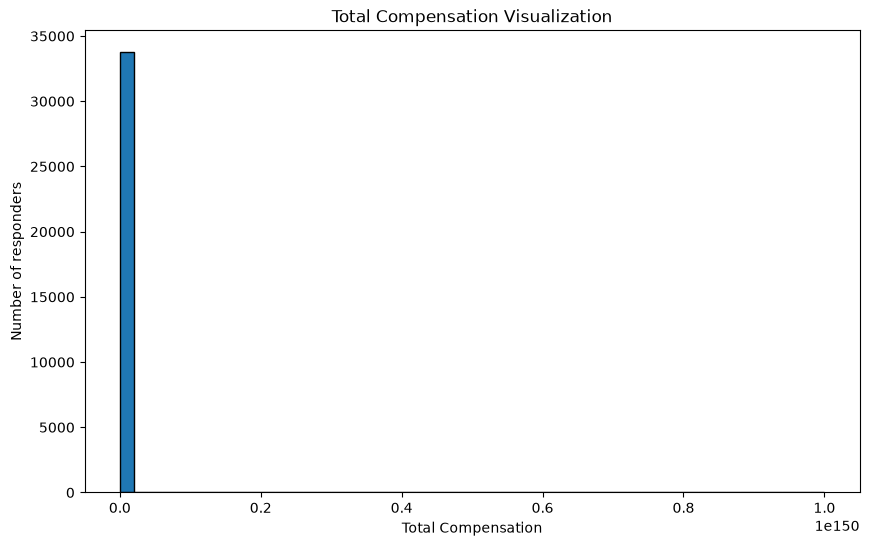

In [24]:
QUERY = "SELECT CompTotal FROM main WHERE CompTotal IS NOT NULL"
df_comp=pd.read_sql_query(QUERY, conn)

plt.figure(figsize=(10,6))
plt.hist(df_comp['CompTotal'], bins= 50, edgecolor ="black")
plt.title("Total Compensation Visualization")
plt.xlabel("Total Compensation")
plt.ylabel("Number of responders")
plt.show()

**1.2 Histogram of YearsCodePro (Years of Professional Coding Experience)**


Objective: Plot a histogram of `YearsCodePro` to analyze the distribution of coding experience among respondents.


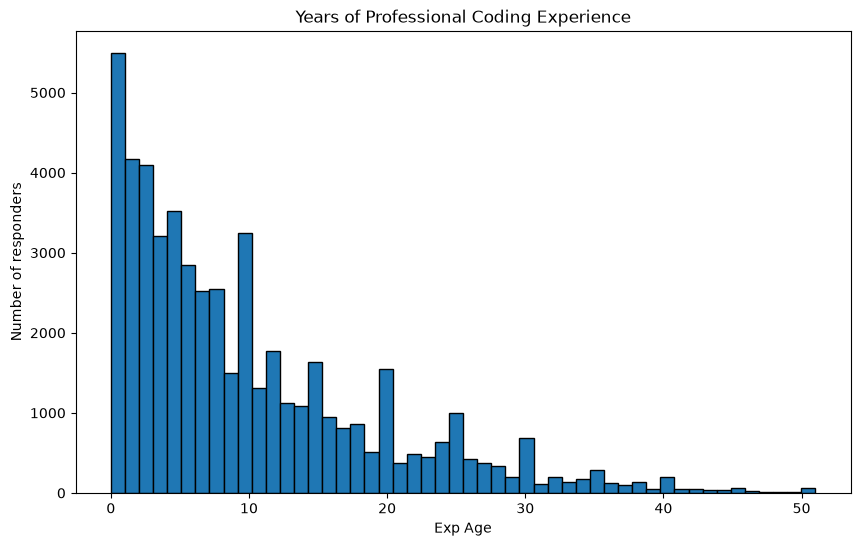

In [33]:
QUERY = "SELECT YearsCodePro FROM main WHERE YearsCodePro IS NOT NULL"
df_code=pd.read_sql_query(QUERY, conn)
df_code['YearsCodePro']= df_code['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df_code['YearsCodePro']= pd.to_numeric(df_code['YearsCodePro'])
plt.figure(figsize=(10, 6))
plt.hist(df_code['YearsCodePro'], bins=50, edgecolor='black')
plt.title('Years of Professional Coding Experience')
plt.xlabel('Exp Age')
plt.ylabel('Number of responders')
plt.show()

### 2. Visualizing Relationships in Data


**2.1 Histogram Comparison of `CompTotal` by `Age` Group**


Objective: Use histograms to compare the distribution of CompTotal across different Age groups.


**Approach:** values above the 95th percentile are excluded so that the age groups can be compared on a readable scale.

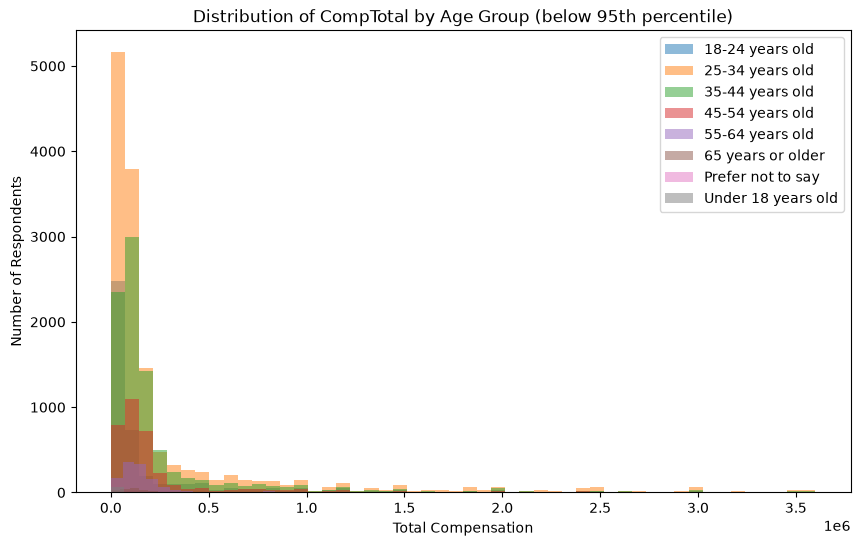

In [41]:
QUERY = "SELECT Age, CompTotal FROM main WHERE Age IS NOT NULL AND CompTotal IS NOT NULL"
df_age_comp=pd.read_sql_query(QUERY, conn)

threshold= df_age_comp['CompTotal'].quantile(0.95)
df_filt= df_age_comp[df_age_comp['CompTotal'] <= threshold]

import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
_ = [plt.hist(df_filt[df_filt['Age'] == age_group]['CompTotal'], bins=50, alpha=0.5, label=age_group) for age_group in sorted(df_filt['Age'].unique())]
plt.title('Distribution of CompTotal by Age Group (below 95th percentile)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.legend()
plt.show()

**2.2 Histogram of TimeSearching for Different Age Groups**


Objective: Use histograms to explore the distribution of `TimeSearching` (time spent searching for information) for respondents across different age groups.


<ArrowStringArray>
[       '30-60 minutes a day',       '60-120 minutes a day',
        '15-30 minutes a day', 'Less than 15 minutes a day',
     'Over 120 minutes a day']
Length: 5, dtype: str

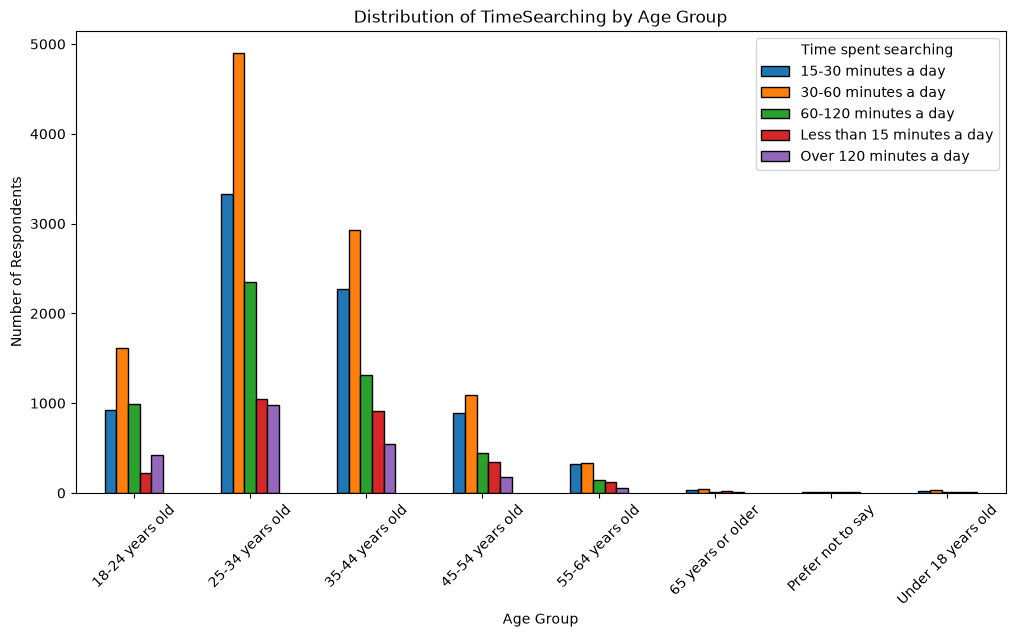

In [42]:
QUERY = "SELECT Age, TimeSearching FROM main WHERE Age IS NOT NULL AND TimeSearching IS NOT NULL"
df_time = pd.read_sql_query(QUERY, conn)
print(df_time['TimeSearching'].unique())

time_table = pd.crosstab(df_time['Age'], df_time['TimeSearching'])
time_table.plot(kind='bar', figsize=(12,6), edgecolor='black')
plt.title('Distribution of TimeSearching by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=45)
plt.legend(title='Time spent searching')
plt.show()

### 3. Visualizing the Composition of Data


**3.1 Histogram of Most Desired Databases (`DatabaseWantToWorkWith`)**


Objective: Visualize the most desired databases for future learning using a histogram of the top 5 databases.


DatabaseWantToWorkWith
PostgreSQL    24005
SQLite        13489
MySQL         12269
MongoDB       10982
Redis         10847
Name: count, dtype: int64

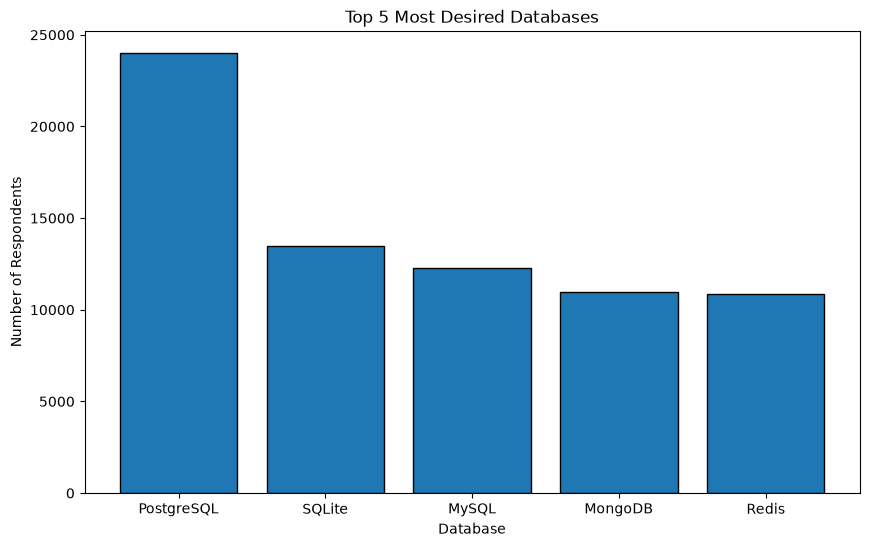

In [43]:
QUERY = "SELECT DatabaseWantToWorkWith FROM main WHERE DatabaseWantToWorkWith IS NOT NULL"
df_db = pd.read_sql_query(QUERY, conn)

db_split = df_db['DatabaseWantToWorkWith'].str.split(';').explode().str.strip()
top5_db = db_split.value_counts().head(5)
print(top5_db)

plt.figure(figsize=(10,6))
plt.bar(top5_db.index, top5_db.values, edgecolor='black')
plt.title('Top 5 Most Desired Databases')
plt.xlabel('Database')
plt.ylabel('Number of Respondents')
plt.show()

**3.2 Histogram of Preferred Work Locations (`RemoteWork`)**


Objective: Use a histogram to explore the distribution of preferred work arrangements (`remote work`).

RemoteWork
Hybrid (some remote, some in-person)    23015
Remote                                  20831
In-person                               10960
Name: count, dtype: int64

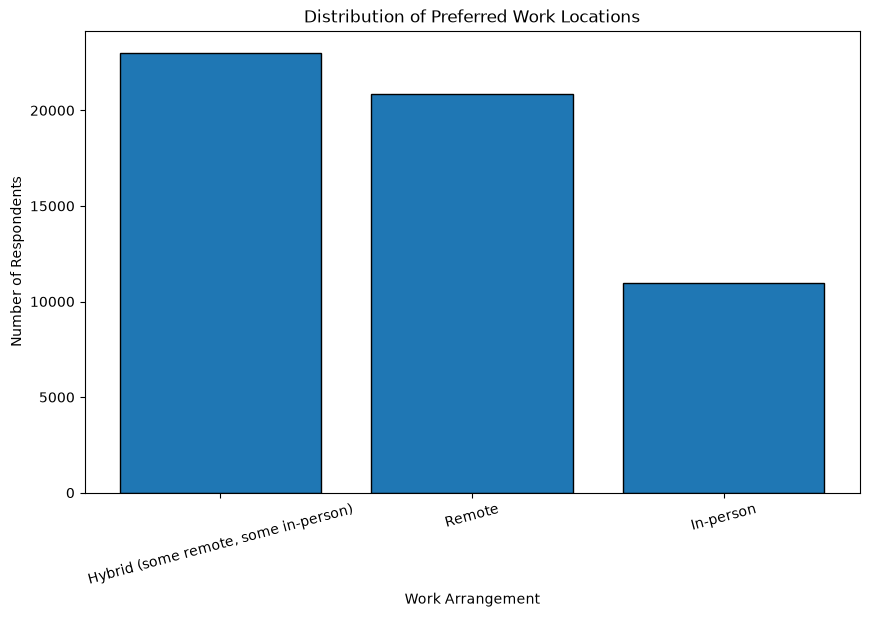

In [44]:
QUERY = "SELECT RemoteWork FROM main WHERE RemoteWork IS NOT NULL"
df_remote = pd.read_sql_query(QUERY, conn)
remote_counts = df_remote['RemoteWork'].value_counts()
print(remote_counts)

plt.figure(figsize=(10,6))
plt.bar(remote_counts.index, remote_counts.values, edgecolor='black')
plt.title('Distribution of Preferred Work Locations')
plt.xlabel('Work Arrangement')
plt.ylabel('Number of Respondents')
plt.xticks(rotation=15)
plt.show()

### 4. Visualizing Comparison of Data


**4.1 Histogram of Median CompTotal for Ages 45 to 60**


Objective: Plot the histogram for `CompTotal` within the age group 45 to 60 to analyze compensation distribution among mid-career respondents.


Median CompTotal (45-64): 127000.0

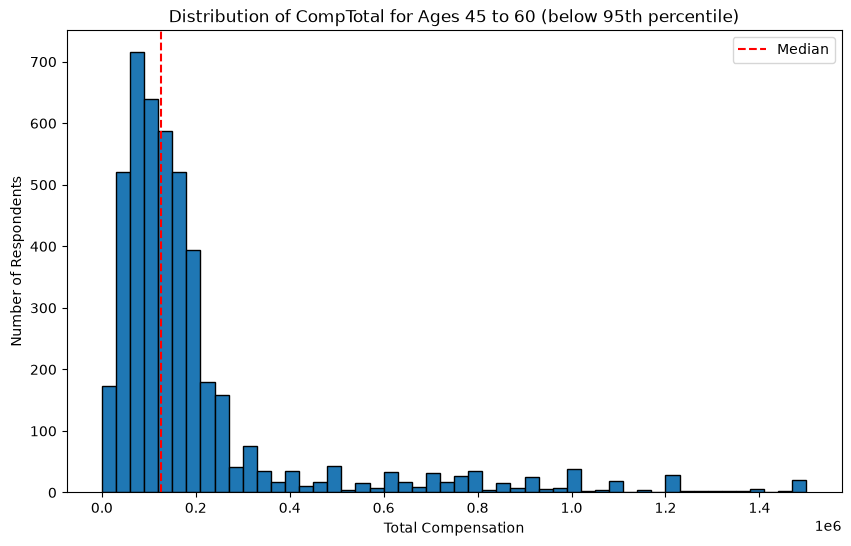

In [50]:
QUERY = "SELECT Age, CompTotal FROM main WHERE CompTotal IS NOT NULL AND Age IN ('45-54 years old', '55-64 years old')"
import sqlite3
conn = sqlite3.connect('survey-data.sqlite')
df_45_60 = pd.read_sql_query(QUERY, conn)

threshold_45_60 = df_45_60['CompTotal'].quantile(0.95)
df_45_60 = df_45_60[df_45_60['CompTotal'] <= threshold_45_60]
median_value = df_45_60['CompTotal'].median()
print('Median CompTotal (45-64):', median_value)

plt.figure(figsize=(10,6))
plt.hist(df_45_60['CompTotal'], bins=50, edgecolor='black')
plt.axvline(median_value, color='red', linestyle='--', label='Median')
plt.title('Distribution of CompTotal for Ages 45 to 60 (below 95th percentile)')
plt.xlabel('Total Compensation')
plt.ylabel('Number of Respondents')
plt.legend()
plt.show()

**4.2 Histogram of Job Satisfaction (`JobSat`) by YearsCodePro**


Objective: Plot the histogram for `JobSat` scores based on respondents' years of professional coding experience.


ExpGroup
0-5      7.0
6-10     7.0
11-20    8.0
21-30    8.0
31+      8.0
Name: JobSat, dtype: float64

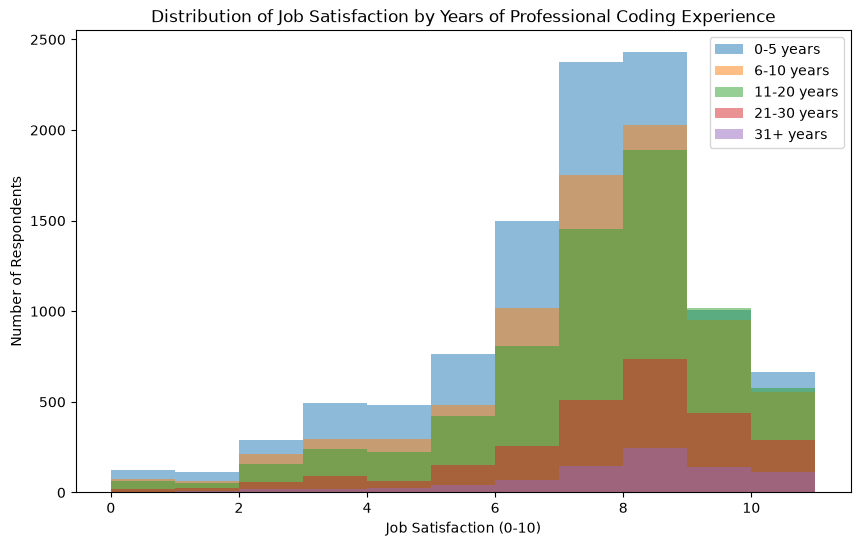

In [46]:
QUERY = "SELECT JobSat, YearsCodePro FROM main WHERE JobSat IS NOT NULL AND YearsCodePro IS NOT NULL"
df_js = pd.read_sql_query(QUERY, conn)
df_js['YearsCodePro'] = df_js['YearsCodePro'].replace({'Less than 1 year': 0, 'More than 50 years': 51})
df_js['YearsCodePro'] = pd.to_numeric(df_js['YearsCodePro'])

groups = ['0-5', '6-10', '11-20', '21-30', '31+']
df_js['ExpGroup'] = pd.cut(df_js['YearsCodePro'], bins=[-1, 5, 10, 20, 30, 51], labels=groups)
print(df_js.groupby('ExpGroup', observed=True)['JobSat'].median())

plt.figure(figsize=(10,6))
_ = [plt.hist(df_js[df_js['ExpGroup'] == g]['JobSat'], bins=11, range=(0, 11), alpha=0.5, label=g + ' years') for g in groups]
plt.title('Distribution of Job Satisfaction by Years of Professional Coding Experience')
plt.xlabel('Job Satisfaction (0-10)')
plt.ylabel('Number of Respondents')
plt.legend()
plt.show()

### Final step: Close the database connection


Once you've completed the lab, make sure to close the connection to the SQLite database:



In [51]:
conn.close()

### Summary


In this lab, you used histograms to visualize various aspects of the dataset, focusing on:

- Distribution of compensation, coding experience, and work hours.

- Relationships in compensation across age groups and work status.

- Composition of data by desired databases and work environments.

- Comparisons of job satisfaction across years of experience.

Histograms helped reveal patterns and distributions in the data, enhancing your understanding of developer demographics and preferences.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
